In [11]:
import pandas as pd
import numpy as np
from types import SimpleNamespace
from src.eval import Evaluator
from src.training import Trainer
from src.models import AutoEncoder
import src.tools as utils

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:

seeds = [3, 7]
metrics = ["AUC-PR", "AUC-ROC", "Standard-F1"]

dfs = []
for seed in seeds:
    df = pd.read_csv(f"results/AutoEncoder/paper_run_stride_{seed}.csv")
    df["seed"] = seed  
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

avg_df = (
    full_df
    .groupby("stride")[["AUC-PR", "AUC-ROC", "Standard-F1", "execution_time"]]
    .mean()
    .reset_index()
)
avg_df[metrics] = avg_df[metrics].round(2)
print(avg_df)

   stride  AUC-PR  AUC-ROC  Standard-F1  execution_time
0       1    0.47     0.86         0.51        0.224710
1      12    0.46     0.85         0.49        0.017395
2      24    0.44     0.84         0.48        0.009200
3      36    0.43     0.82         0.47        0.006657
4      48    0.41     0.82         0.45        0.005506
5      60    0.40     0.80         0.44        0.004420
6      72    0.39     0.79         0.43        0.004079
7      84    0.38     0.78         0.42        0.003607
8      96    0.37     0.78         0.41        0.003462


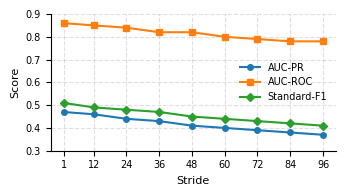

In [3]:
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.5,
})

metrics = ["AUC-PR", "AUC-ROC", "Standard-F1"]

fig, ax = plt.subplots(figsize=(3.5, 2))

markers = ['o', 's', 'D']

for metric, marker in zip(metrics, markers):
    ax.plot(
        avg_df["stride"],
        avg_df[metric],
        marker=marker,
        markersize=4,
        label=metric
    )
strides = sorted(avg_df["stride"].unique())
ax.set_xticks(strides)
ax.set_xticklabels([str(s) for s in strides])
ax.set_xlabel("Stride")
ax.set_ylabel("Score")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.ylim(0.3, 0.9)
plt.tight_layout()

plt.savefig("Figures/stride_impact.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()

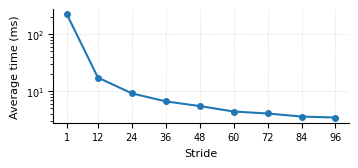

In [4]:
fig, ax = plt.subplots(figsize=(3.5, 1.6))

ax.plot(
    avg_df["stride"],
    avg_df["execution_time"] * 1000 ,
    marker='o',
    markersize=4
)

strides = sorted(avg_df["stride"].unique())
ax.set_xticks(strides)
ax.set_xticklabels([str(s) for s in strides])

ax.set_xlabel("Stride")
ax.set_ylabel("Average time (ms)")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_yscale("log")
ax.grid(True, which="major", linestyle="--", alpha=0.3, linewidth=0.6)

plt.tight_layout(pad=0.5)

# Save
plt.savefig("Figures/execution_time.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()

In [5]:
win_size = 96
epochs = 50
hidden_ratios = [0.5, 0.25]
config = SimpleNamespace(
    task_name="anomaly_detection",
    seq_len=win_size,
    enc_in=1,
    hidden_ratios=hidden_ratios,
    activation="relu",
)

scheduled_lr_scheduler = "plateau"
scheduled_lr_scheduler_kwargs = {
    "patience": 5,
    "factor": 0.5,
    "min_lr": 1e-5,
}
trainer = Trainer(
    batch_size=1024,
    lr=1e-2,
    device='cuda',
    win_size=win_size,
    validation_size=0.2,
    lr_scheduler=scheduled_lr_scheduler,
    lr_scheduler_kwargs=scheduled_lr_scheduler_kwargs
)
evaluator = Evaluator(
    batch_size=1000,
    device='cuda',
    metrics='restr',
    strategy='overlapping'
)

In [8]:
model = AutoEncoder.Model(config)

In [9]:
path = 'Datasets/TSB-AD-U/'
file_list = 'Datasets/File_List/TSB-AD-U-Eva.csv'
file_list = pd.read_csv(file_list)['file_name'].values

In [36]:
filename = file_list[100]
data_train, data, labels = utils.read_file(path, filename)
trainer.train(model, data_train, epochs)

In [51]:
reconstruction_error = evaluator.reconstruction_error(
            data, model, win_size, 1)

reconstruction = evaluator._mse_reconstruction(data, model, win_size).cpu()

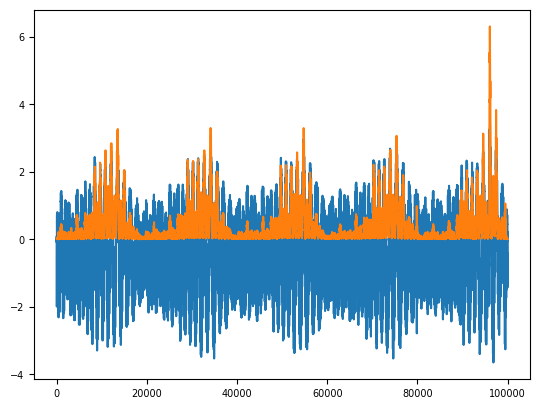

In [52]:
plt.plot(data)
plt.plot(reconstruction)

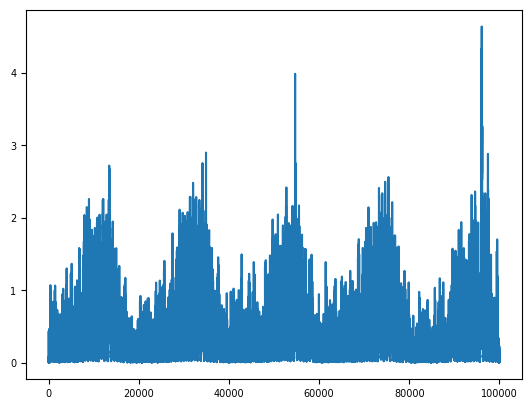

In [28]:
plt.plot(reconstruction_error)